In [21]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

In [22]:
#load data and EDA
df = pd.read_csv("customer_churn.csv")

print(df.head())

print(df.shape)

print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [23]:
print(df.isnull().sum())
(df == " ").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [24]:
#data cleaning
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

/tmp/ipykernel_3103/1160026402.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


In [25]:
df.drop("customerID", axis=1, inplace=True)

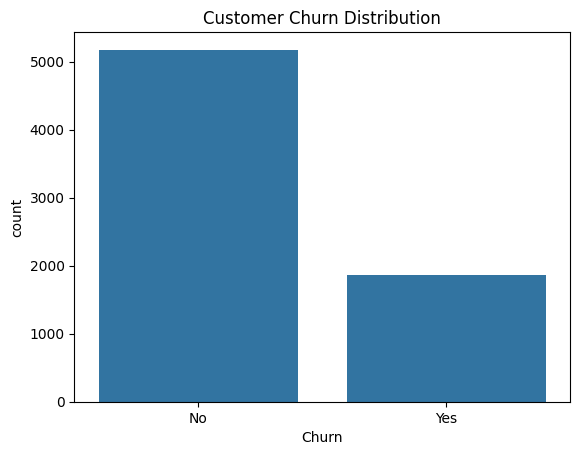

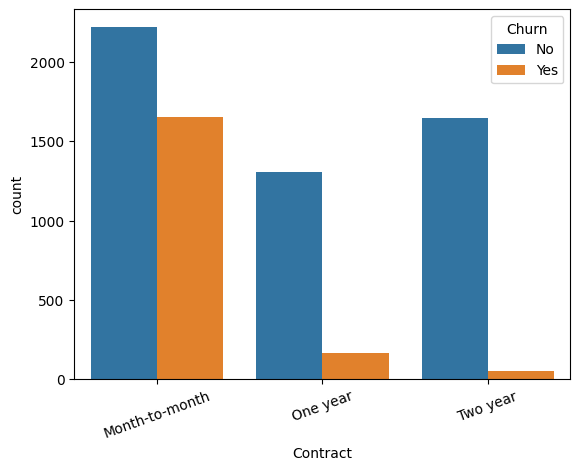

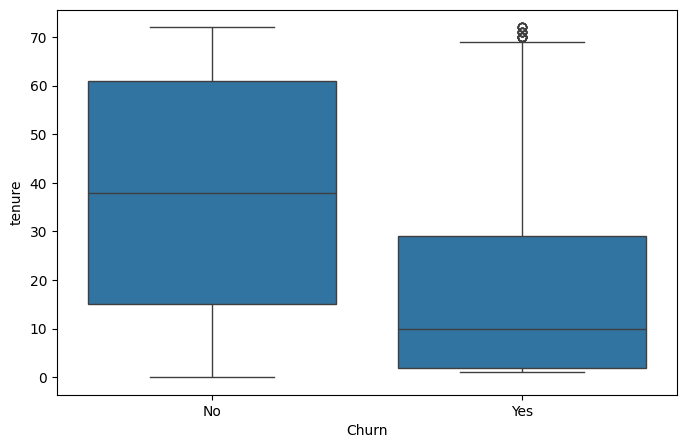

In [26]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=20)

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.show()

In [27]:
#encode target
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [29]:
X = df.drop("Churn", axis=1)

y = df["Churn"]
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42
        )
    )
])
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [37]:
pred = rf_model.predict(X_test)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test,pred))

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy: 0.7814052519517388
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



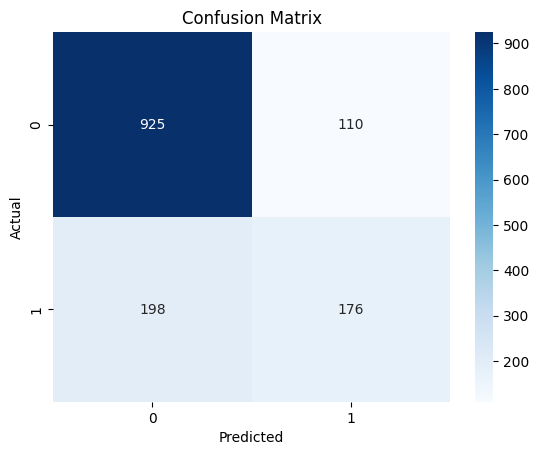

In [38]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [39]:
rf = rf_model.named_steps["classifier"]
feature_names = rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                                Feature  Importance
3                     num__TotalCharges    0.142162
1                           num__tenure    0.130349
2                   num__MonthlyCharges    0.122673
36         cat__Contract_Month-to-month    0.072880
18               cat__OnlineSecurity_No    0.038525
38               cat__Contract_Two year    0.035327
27                  cat__TechSupport_No    0.032809
43  cat__PaymentMethod_Electronic check    0.029003
16     cat__InternetService_Fiber optic    0.027833
21                 cat__OnlineBackup_No    0.017058
0                    num__SeniorCitizen    0.016559
5                      cat__gender_Male    0.016149
4                    cat__gender_Female    0.015798
39             cat__PaperlessBilling_No    0.014399
40            cat__PaperlessBilling_Yes    0.014397


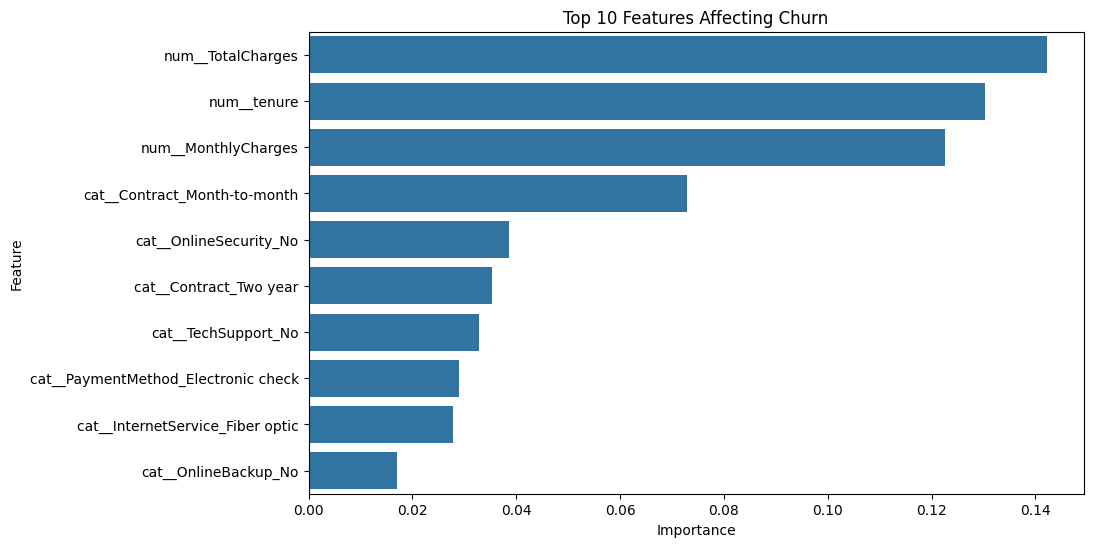

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Features Affecting Churn"
)

plt.show()